In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, Input, PReLU, BatchNormalization
from tensorflow.keras import initializers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import os
import cv2

In [2]:
import glob

T = 1
data_dir = 'C:/Users/jamin/turb/temporal/dataset/2Ddecay/CnnNPY'
file_list = sorted(glob.glob(os.path.join(data_dir, 'vorticity*.npy')))

X, Y = [], []

for file_path in file_list:
    data = np.load(file_path)  # shape: (500, 128, 128)

    if data.shape[0] <= T:
        print(f"{file_path} 는 timestep이 {T}보다 작습니다!")
        continue

    for t in range(450, 500 - T):
        x_t = data[t][..., np.newaxis]
        y_t = data[t + T][..., np.newaxis]

        # squeeze로 혹시 남은 차원 제거
        x_t = np.squeeze(x_t)
        y_t = np.squeeze(y_t)

        x_t = x_t[..., np.newaxis]  # 확실히 (128, 128, 1)
        y_t = y_t[..., np.newaxis]

        X.append(x_t)
        Y.append(y_t)

# numpy 배열로 변환 + reshape로 불필요한 차원 제거
X = np.array(X).reshape(-1, 128, 128, 1)
Y = np.array(Y).reshape(-1, 128, 128, 1)

print("데이터 생성 완료")
print("X shape:", X.shape)
print("Y shape:", Y.shape)


데이터 생성 완료
X shape: (2450, 128, 128, 1)
Y shape: (2450, 128, 128, 1)


In [3]:
# z-score 정규화 및 역정규화 함수 정의
def normalize_zscore(data, mean=None, std=None):
    """
    Z-score normalization: (data - mean) / std
    If mean and std are not provided, compute them from data.
    
    Parameters:
    - data : np.ndarray
    - mean : optional, float
    - std  : optional, float
    
    Returns:
    - normalized data
    - mean used
    - std used
    """
    if mean is None:
        mean = np.mean(data)
    if std is None:
        std = np.std(data) + 1e-8  # avoid division by zero
    norm = (data - mean) / std
    return norm, mean, std

def denormalize_zscore(norm_data, mean, std):
    """
    Reverse z-score normalization.
    Returns original-scale data.
    """
    return norm_data * std + mean

In [7]:
print(std)
print(mean)

1.0930730496782437
-6.032643233028552e-11


In [5]:
# 학습용 데이터 정규화
X_norm, mean, std = normalize_zscore(X)
Y_norm = (Y - mean) / std

In [8]:
print("정답 X의 범위:", X_norm.min(), X_norm.max())
print("정답 Y의 범위:", Y_norm.min(), Y_norm.max())

정답 X의 범위: -7.744523572721441 7.9695314074613535
정답 Y의 범위: -7.744523572721441 7.923185008183727


In [9]:
# Train/Validation/Test split
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X_norm, Y_norm, test_size=0.2, random_state=42, shuffle=False
)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42, shuffle=False
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (1960, 128, 128, 1)
Val shape: (245, 128, 128, 1)
Test shape: (245, 128, 128, 1)


In [10]:
# TensorFlow Dataset 변환
batch_size = 16

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, Y_val)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, Y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [30]:
# 논문 코드 검증
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, LeakyReLU, AveragePooling2D, Concatenate
from tensorflow.keras.saving import register_keras_serializable

# ConvBlock 정의
@register_keras_serializable()
class ConvBlock(tf.keras.layers.Layer):
    def __init__(self, filters, transposed=False):
        super().__init__()
        self.conv1 = Conv2D(filters[0], 3, padding='same')
        self.act1 = LeakyReLU(0.2)

        self.conv2 = Conv2D(filters[1], 3, padding='same')
        self.act2 = LeakyReLU(0.2)

        self.conv3 = Conv2D(filters[2], 3, padding='same')
        self.act3 = LeakyReLU(0.2)

        self.transposed = transposed
        if transposed:
            self.trans_conv = Conv2DTranspose(filters[2], 3, padding='same')

    def call(self, x):
        x = self.act1(self.conv1(x))
        x = self.act2(self.conv2(x))
        x = self.act3(self.conv3(x))
        if self.transposed:
            x = self.trans_conv(x)
        return x

# Multi-scale Prediction Net 정의
@register_keras_serializable()
class MultiScalePredictionNet(Model):
    def __init__(self):
        super().__init__()
        # Convblk layers
        self.convblk5 = ConvBlock([64, 64, 64])
        self.convblk4 = ConvBlock([64, 64, 64])
        self.convblk3 = ConvBlock([64, 64, 64])
        self.convblk2 = ConvBlock([64, 64, 64])
        self.convblk1 = ConvBlock([32, 32, 32])
        self.convblk0 = ConvBlock([16, 16, 1], transposed=True)  # includes transposed conv

        # Upsampling 레이어 (transposed conv)
        self.up5 = Conv2DTranspose(64, 4, strides=2, padding='same')  # 4 → 8
        self.up4 = Conv2DTranspose(64, 4, strides=2, padding='same')  # 8 → 16
        self.up3 = Conv2DTranspose(64, 4, strides=2, padding='same')  # 16 → 32
        self.up2 = Conv2DTranspose(64, 4, strides=2, padding='same')  # 32 → 64
        self.up1 = Conv2DTranspose(32, 4, strides=2, padding='same')  # 64 → 128

        # 최종 출력
        self.final_conv = Conv2D(1, 3, padding='same')

    def call(self, x_input):
        # 평균 풀링으로 multi-scale 입력 생성: X^(1) ~ X^(4)
        x_pooled = x_input
        pooled_inputs = []
        for _ in range(4):
            x_pooled = AveragePooling2D(pool_size=2)(x_pooled)
            pooled_inputs.append(x_pooled)

        # X^(5)
        x5 = x_input
        for _ in range(5):
            x5 = AveragePooling2D(pool_size=2)(x5)

        # 인코더-디코더 흐름 + skip connection
        h5 = self.convblk5(x5)
        h5_up = self.up5(h5)

        h4_input = Concatenate(axis=-1)([h5_up, pooled_inputs[3]])
        h4 = self.convblk4(h4_input)
        h4_up = self.up4(h4)

        h3_input = Concatenate(axis=-1)([h4_up, pooled_inputs[2]])
        h3 = self.convblk3(h3_input)
        h3_up = self.up3(h3)

        h2_input = Concatenate(axis=-1)([h3_up, pooled_inputs[1]])
        h2 = self.convblk2(h2_input)
        h2_up = self.up2(h2)

        h1_input = Concatenate(axis=-1)([h2_up, pooled_inputs[0]])
        h1 = self.convblk1(h1_input)
        h1_up = self.up1(h1)

        h0 = self.convblk0(h1_up)  # includes transposed conv

        return self.final_conv(h0)
    
    def get_config(self):
        config = super().get_config()  # 기본 설정 받아오기
        return config  # 특별한 인자 없으면 그대로 반환

    @classmethod
    def from_config(cls, config):
        return cls(**config)
    
def cnn_loss(y_true, y_pred, model, sigma1=1, sigma2=1e-4):
    """
    논문 기반 loss function:
    L = σ₁ * MSE + σ₂ * L2(weight regularization)
    """
    mse = tf.reduce_mean(tf.square(y_true - y_pred))

    l2_reg = tf.add_n([
        tf.nn.l2_loss(var)
        for var in model.trainable_variables
        if 'kernel' in var.name  # bias는 제외
    ])

    return sigma1 * mse + sigma2 * l2_reg


In [31]:
import os
import pickle
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import MeanAbsoluteError

# 경로 설정
history_dir = "C:/Users/jamin/turb/temporal/dataset/2Ddecay/history_logs"
model_dir = "C:/Users/jamin/turb/temporal/dataset/2Ddecay/model"
os.makedirs(history_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

# ----------------------------------------------------------------------------------
# Loss 클래스 정의 (논문: MSE + (1/2)‖W‖²)
# ----------------------------------------------------------------------------------
class CNNLoss(tf.keras.losses.Loss):
    def __init__(self, model, sigma1=1, sigma2=1e-4):  # sigma1 = 1 / (N_x * N_y) = 1 / (128 * 128)
        super().__init__()
        self.model = model
        self.sigma1 = sigma1
        self.sigma2 = sigma2

    def call(self, y_true, y_pred):
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        l2_reg = tf.add_n([
            tf.nn.l2_loss(v) for v in self.model.trainable_variables if 'kernel' in v.name
        ])
        return self.sigma1 * mse + self.sigma2 * l2_reg

# ----------------------------------------------------------------------------------
# 모델 생성 및 컴파일
# ----------------------------------------------------------------------------------
model = MultiScalePredictionNet()
optimizer = Adam(learning_rate=1e-3)
loss_fn = CNNLoss(model, sigma1=1, sigma2=1e-4)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[MeanAbsoluteError()]
)

# ----------------------------------------------------------------------------------
# 콜백 설정 (모델 저장)
# ----------------------------------------------------------------------------------
checkpoint_path = os.path.join(model_dir, 'best_model.keras')
model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False
)

# ----------------------------------------------------------------------------------
# 모델 학습
# ----------------------------------------------------------------------------------
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=500,
    batch_size=16,
    callbacks=[model_checkpoint],
    verbose=1
)

# ----------------------------------------------------------------------------------
# 학습 이력 저장
# ----------------------------------------------------------------------------------
history_path = os.path.join(history_dir, 'history_final.pkl')
with open(history_path, 'wb') as f:
    pickle.dump(history.history, f)

print(f"모델 저장 완료: {checkpoint_path}")
print(f"학습 기록 저장 완료: {history_path}")


Epoch 1/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 24s 163ms/step - loss: 0.5389 - mean_absolute_error: 0.4872 - val_loss: 0.2117 - val_mean_absolute_error: 0.3277
Epoch 2/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 19s 157ms/step - loss: 0.2017 - mean_absolute_error: 0.3203 - val_loss: 0.1665 - val_mean_absolute_error: 0.2894
Epoch 3/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 21s 168ms/step - loss: 0.1604 - mean_absolute_error: 0.2840 - val_loss: 0.1444 - val_mean_absolute_error: 0.2678
Epoch 4/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - loss: 0.1416 - mean_absolute_error: 0.2658 - val_loss: 0.1385 - val_mean_absolute_error: 0.2644
Epoch 5/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 21s 167ms/step - loss: 0.1338 - mean_absolute_error: 0.2588 - val_loss: 0.1290 - val_mean_absolute_error: 0.2540
Epoch 6/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - loss: 0.1272 - mean_absolute_error: 0.2531 - val_loss: 0.1247 - val_mean_absolute_error: 0.2505
Epoch 7/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 22s 179ms/step - loss: 0.1221 - mea

In [9]:
# 경로 설정 (필요시 수정)
history_dir = "C:/Users/jamin/turb/temporal/dataset/2Ddecay/history_logs"
os.makedirs(history_dir, exist_ok=True)
history_path = os.path.join(history_dir, 'history_1.pkl')

# 저장
with open(history_path, 'wb') as f:
    pickle.dump(history.history, f)

print(f"히스토리 저장 완료: {history_path}")

NameError: name 'pickle' is not defined

In [ ]:
# 모델 저장 경로
model_path = "C:/Users/jamin/turb/temporal/dataset/2Ddecay/model/best_model_T1_Lee.keras"

# 모델 저장 (.keras 형식 = 구조 + 가중치 + 컴파일 설정 포함)
model.save(model_path)
print(f"모델 저장 완료: {model_path}")


✅ 모델 저장 완료: C:/Users/jamin/turb/temporal/dataset/2Ddecay/model/best_model_T1_Lee.keras


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


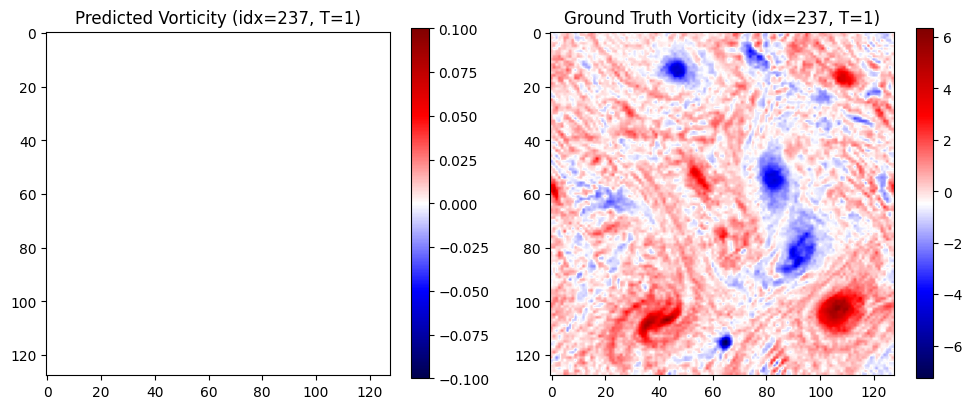

In [ ]:
# 입력 프레임
n = np.random.randint(1, 243)
# n = 243
initial_input = X_test[n]  # shape: (128, 128, 1)
current_input = np.expand_dims(initial_input, axis=0)  # shape: (1, 128, 128, 1), 모델에 입력하기 위해선 batch_size 차원이 필요하기에 expand

'''
# 모델 불러오기 (t->t+T 예측 모델)
model_path = 'C:/Users/jamin/turb/temporal/dataset/2Ddecay/model/best_model_T1_Lee_1.keras'
model = tf.keras.models.load_model(
    model_path,
    custom_objects={
        "MultiScalePredictionNet": MultiScalePredictionNet,
        "CNNLoss": CNNLoss
    },
    safe_mode=False
)
'''

# 예측
next_output = model.predict(current_input)  # shape: (1, 128, 128, 1)
predicted_frame = next_output[0]

# 역정규화
# predicted_frame = inverse_normalize(predicted_frame, vmin, vmax)
# ground_truth = inverse_normalize(X_test[n+T], vmin, vmax)  # 실제 t+T번째 스냅샷
predicted_frame = denormalize_zscore(predicted_frame, mean, std)
ground_truth = denormalize_zscore(X_test[n+T], mean, std)

# 시각화
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title(f"Predicted Vorticity (idx={n+1}, T=1)")
plt.imshow(predicted_frame, cmap='seismic')  # or 'bwr', 'RdBu'
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title(f"Ground Truth Vorticity (idx={n+1}, T=1)")
plt.imshow(ground_truth, cmap='seismic')
plt.colorbar()

plt.tight_layout()
plt.show()

In [12]:
# ------------------------------------------------------------------------------
# [Function Name] energy_spectrum_from_vorticity
# ------------------------------------------------------------------------------
# Computes the energy spectrum from the vorticity field (omega) in 2D.
# Input  : (L, nx, ny, w)  => domain size, grid points, and vorticity
# Output : (en, n)         => 1D energy spectrum and maximum wavenumber index
def energy_spectrum_from_vorticity(L, nx, ny, w):
    '''
    Compute the energy spectrum from a 2D vorticity field.

    Inputs
    ------
    L     : Domain length
    nx,ny : Number of grid points in x and y
    w     : Vorticity field (2D)

    Output
    ------
    en : 1D energy spectrum
    n  : Maximum wavenumber index
    '''
    epsilon = 1.0e-6
    dx = L/nx

    kx = np.empty(nx)
    ky = np.empty(ny)
    
    kx[0:int(nx/2)] = 2*np.pi/(float(nx)*dx)*np.arange(0,int(nx/2))
    kx[int(nx/2):nx] = 2*np.pi/(float(nx)*dx)*np.arange(-int(nx/2),0)
    ky[0:ny] = kx[0:ny]
    
    kx[0] = epsilon
    ky[0] = epsilon

    kx, ky = np.meshgrid(kx, ky, indexing='ij')
    
    a = pyfftw.empty_aligned((nx,ny), dtype='complex128')
    b = pyfftw.empty_aligned((nx,ny), dtype='complex128')

    fft_object = pyfftw.FFTW(a, b, axes=(0,1), direction='FFTW_FORWARD')
    wf = fft_object(w[0:nx, 0:ny]) 
    
    es = np.empty((nx,ny))
    kk = np.sqrt(kx**2 + ky**2)
    # Energy spectrum from vorticity ~ pi * (|w_hat|^2 / k)
    es[:,:] = np.pi * ((np.abs(wf)/(nx*ny))**2) / kk
    
    n = int(np.sqrt(nx*nx + ny*ny)/2.0)-1
    en = np.zeros(n+1)
    
    # Shell averaging
    for k in range(1,n+1):
        ii, jj = np.where((kk[1:,1:]>(k-0.5)) & (kk[1:,1:]<(k+0.5)))
        ic = ii.size
        ii = ii+1
        jj = jj+1
        en[k] = np.sum(es[ii,jj])
        en[k] = en[k]/ic
        
    return en, n

In [13]:
from numpy.fft import fft2, fftshift

def energy_spectrum_from_vorticity_numpy(L, nx, ny, w):
    """
    Compute 1D energy spectrum from a 2D vorticity field using numpy.
    
    Parameters:
    L   : domain length (assumed square domain LxL)
    nx  : number of grid points in x
    ny  : number of grid points in y
    w   : 2D vorticity field (shape: [nx, ny])
    
    Returns:
    en : 1D energy spectrum
    n  : maximum wavenumber index
    """
    epsilon = 1e-6
    dx = L / nx

    # Wavenumber vectors
    kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(ny, d=dx) * 2 * np.pi
    kx[0] = epsilon
    ky[0] = epsilon
    kx, ky = np.meshgrid(kx, ky, indexing='ij')
    kk = np.sqrt(kx**2 + ky**2)

    # FFT of vorticity
    w_hat = fft2(w)
    w_hat = fftshift(w_hat)
    kk = fftshift(kk)

    # Energy spectrum from vorticity (E(k) ~ |ω̂|² / k)
    E_2d = np.pi * (np.abs(w_hat / (nx * ny)) ** 2) / (kk + epsilon)

    # Shell averaging
    n = int(np.sqrt(nx**2 + ny**2) / 2.0) - 1
    en = np.zeros(n + 1)
    for k in range(1, n + 1):
        mask = (kk > (k - 0.5)) & (kk < (k + 0.5))
        count = np.count_nonzero(mask)
        if count > 0:
            en[k] = np.sum(E_2d[mask]) / count

    return en, n

In [14]:
def smooth_spectrum(spectrum, window_size=3):
    return np.convolve(spectrum, np.ones(window_size)/window_size, mode='same')

def plot_energy_spectrum_comparison(w_pred, w_true, domain_size=1.0, label_pred='Prediction', label_true='Ground Truth'):
    """
    w_pred, w_true : 2D vorticity fields (shape: [H, W] or [H, W, 1])
    domain_size     : domain length (L) assumed square
    """

    # squeeze if necessary
    if w_pred.ndim == 3:
        w_pred = w_pred[..., 0]
    if w_true.ndim == 3:
        w_true = w_true[..., 0]

    nx, ny = w_pred.shape

    # spectrum 계산
    en_pred, n_pred = energy_spectrum_from_vorticity_numpy(domain_size, nx, ny, w_pred)
    en_true, n_true = energy_spectrum_from_vorticity_numpy(domain_size, nx, ny, w_true)

    en_true_smooth = smooth_spectrum(en_true)
    en_pred_smooth = smooth_spectrum(en_pred)

    # 공통 파수축
    k = np.arange(1, min(n_pred, n_true) + 1, dtype=float)

    threshold = 1e-3  # 원하는 최소 에너지 값 설정

    # mask 생성
    mask_true = en_true_smooth[1:] > threshold
    mask_pred = en_pred_smooth[1:] > threshold

    # k는 k = 1, 2, ..., N
    k_masked = k[mask_true]
    en_true_filtered = en_true_smooth[1:][mask_true]

    k_masked_pred = k[mask_pred]
    en_pred_filtered = en_pred_smooth[1:][mask_pred]

    # 시각화
    plt.figure(figsize=(6, 5))
    plt.loglog(k_masked, en_true_filtered, 'b-', label='GT')
    plt.loglog(k_masked_pred, en_pred_filtered, 'orange', linestyle='--', label='Pred ')

    # 이론 기울기 참조선 (k^-1)
    k_fit = k[10:30]  # 적당한 영역
    ref_line = k_fit ** (-1)
    ref_line *= en_true[10] / ref_line[0]
    plt.loglog(k_fit, ref_line, 'k-.', label=r'$k^{-1}$ ref')

    plt.xlabel("Wavenumber $k$")
    plt.ylabel("Spectrum $E(k)$")
    plt.title("Vorticity-Based Spectrum Comparison")
    plt.grid(True, which='both', ls='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

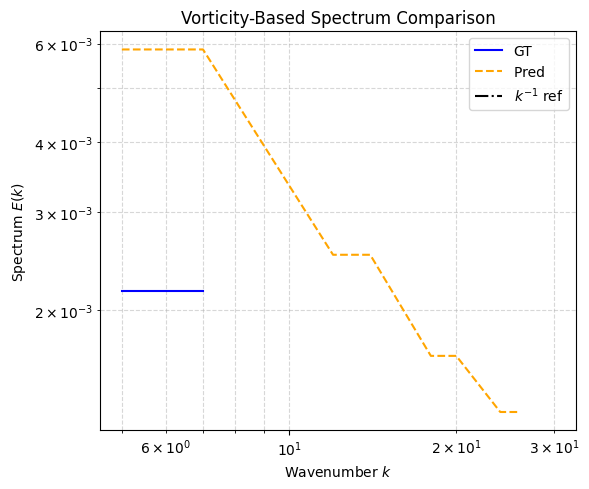

In [15]:
# vorticity 예측 결과와 실제값: shape (128, 128, 1)
w_pred = predicted_frame[0]
w_true = ground_truth[0]

plot_energy_spectrum_comparison(w_pred, w_true)

In [16]:
def compute_vorticity_pdf(w, bins=100, range=None, density=True, plot=False):
    """
    2D vorticity field에 대한 PDF를 계산하고 선택적으로 시각화합니다.

    Parameters:
    w        : 2D numpy array, vorticity field (shape: [H, W] or [H, W, 1])
    bins     : histogram 구간 수 (default: 100)
    range    : 히스토그램 범위 (예: (-50, 50)), 없으면 자동 계산
    density  : True면 확률 밀도로 정규화됨 (default)
    plot     : True면 PDF plot 시각화

    Returns:
    pdf_vals : PDF 값 (y축)
    bin_centers : 각 bin의 중심값 (x축)
    """
    # squeeze for (H, W, 1) → (H, W)
    if w.ndim == 3:
        w = w[..., 0]

    # 1D로 flatten
    w_flat = w.flatten()

    # histogram 계산
    hist, bin_edges = np.histogram(w_flat, bins=bins, range=range, density=density)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    if plot:
        plt.figure(figsize=(6, 4))
        plt.plot(bin_centers, hist, label='Vorticity PDF')
        plt.xlabel(r'$\omega$')
        plt.ylabel('Probability Density')
        plt.grid(True, ls='--', alpha=0.5)
        plt.title('Vorticity PDF')
        plt.tight_layout()
        plt.show()

    return hist, bin_centers

In [17]:
def compare_vorticity_pdf(w_pred, w_true, bins, vmin=None, vmax=None, label_pred='Prediction', label_true='Ground Truth'):
    """
    전체 vorticity 값에 대한 예측 vs 정답 PDF 비교를 수행하고 시각화합니다.

    Parameters:
    w_pred, w_true : 2D or 3D array (shape: [..., 1] or [...])
    bins           : 히스토그램 구간 수
    vmin, vmax     : x축 범위 (None이면 자동 설정)
    label_pred     : 예측 데이터 라벨
    label_true     : 정답 데이터 라벨
    """
    # flatten
    w_pred_flat = w_pred.flatten()
    w_true_flat = w_true.flatten()

    # 범위 설정
    if vmin is None:
        vmin = min(w_true_flat.min(), w_pred_flat.min())
    if vmax is None:
        vmax = max(w_true_flat.max(), w_pred_flat.max())
    hist_range = (vmin, vmax)

    # 히스토그램 계산
    plt.figure(figsize=(6, 4))
    plt.hist(w_true_flat, bins=bins, range=hist_range, density=True, alpha=0.5, label=label_true)
    plt.hist(w_pred_flat, bins=bins, range=hist_range, density=True, alpha=0.5, label=label_pred)

    # 라벨링 및 시각화
    plt.xlabel(r'Vorticity $\omega$')
    plt.ylabel('Probability Density')
    plt.title('Vorticity PDF Comparison')
    plt.grid(True, ls='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


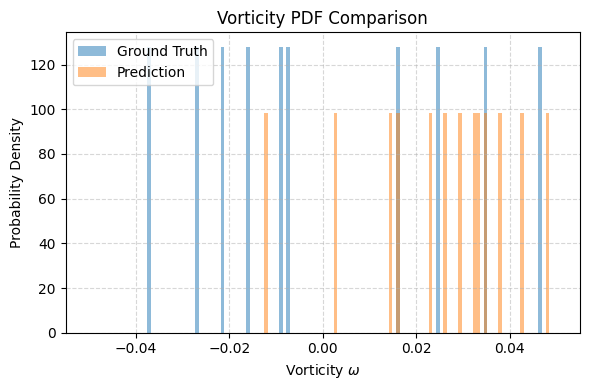

In [83]:
compare_vorticity_pdf(w_pred, w_true, bins=128, vmin=-0.05, vmax=0.05)

In [ ]:
# 와류 gif 만드는 코드

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ==== 데이터 로딩 ====
data = np.load('../../Desktop/newModel/vorticity/vorticity50_500_128.npy')  # case 50, size: (500, 128, 128)
dt = 0.1
timesteps = data.shape[0]

save_path = 'vorticity_new_raw.gif'

fig, ax = plt.subplots(figsize=(5, 5))
vmin, vmax = data.min(), data.max()

def update(frame):
    ax.clear()
    ax.imshow(data[frame], cmap='RdBu', vmin=vmin, vmax=vmax)
    ax.set_title(f"Vorticity (t={round((frame+1)*dt, 1)}s)", fontsize=14)
    ax.axis('off')

ani = animation.FuncAnimation(fig, update, frames=timesteps, interval=20) #interval 100: 프레임당 0.1초
ani.save(save_path, writer='pillow')